# FX Volatility Regime Detection — Hidden Markov Model

Unsupervised detection of volatility regimes in EUR/USD using a Gaussian Hidden Markov Model, on **real data**.

- **Data:** daily EUR/USD from Yahoo Finance (2004–present).
- **Features:** daily log returns and short-window realized volatility.
- A 3-state Gaussian HMM learns hidden states; states are labelled **Low / Medium / High volatility** by their realized-vol level.
- Output: time spent in each regime, regime-dependent return and volatility, regime persistence, and a regime-coloured price chart.

The regimes are statistical constructs, not ground truth — they depend on the number of states and the feature set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

TICKER="EURUSD=X"; START="2004-01-01"
N_STATES=3; VOL_WINDOW=5; SEED=42; TRADING_DAYS=252

Matplotlib is building the font cache; this may take a moment.


In [2]:
%pip install hmmlearn scikit-learn yfinance

Note: you may need to restart the kernel to use updated packages.


## 1. Load real EUR/USD data and build features

In [3]:
import yfinance as yf
px = yf.download(TICKER, start=START, progress=False)["Close"].ffill().dropna()
px = px.squeeze()

ret  = np.log(px).diff()
rvol = ret.rolling(VOL_WINDOW).std()
feat = pd.DataFrame({"ret": ret, "rvol": rvol}).dropna()
print(f"{len(feat)} trading days, {feat.index[0].date()} to {feat.index[-1].date()}")
feat.tail()

5818 trading days, 2004-01-08 to 2026-06-12


,ret,rvol
Date,,
2026-06-08,-0.007785,0.003192
2026-06-09,0.000507,0.003405
2026-06-10,0.000600,0.003580
2026-06-11,0.000023,0.003646
2026-06-12,0.003791,0.004300


## 2. Fit the Hidden Markov Model and label regimes

In [4]:
X = StandardScaler().fit_transform(feat.values)
model = GaussianHMM(n_components=N_STATES, covariance_type="full",
                    n_iter=200, random_state=SEED)
model.fit(X)
states = pd.Series(model.predict(X), index=feat.index)

# label hidden states by their average realized volatility
order = feat.groupby(states)["rvol"].mean().sort_values().index
names = ["Low vol", "Medium vol", "High vol"][:N_STATES]
label_map = {st: n for st, n in zip(order, names)}
regime = states.map(label_map)
print("Converged:", model.monitor_.converged)
print("Regimes:", list(regime.unique()))

Converged: True
Regimes: ['Low vol', 'Medium vol', 'High vol']


## 3. Regime characteristics

In [5]:
summary = pd.DataFrame({
    "Time share":      regime.value_counts(normalize=True),
    "Annual return":   feat["ret"].groupby(regime).mean()*TRADING_DAYS,
    "Annual vol":      feat["ret"].groupby(regime).std()*np.sqrt(TRADING_DAYS),
}).reindex(names)
print("Regime characteristics:")
print((summary*100).round(1).astype(str).apply(lambda c: c+"%").to_string())

# average regime persistence (expected duration in days) from the transition matrix
dur = {label_map[i]: 1/(1-model.transmat_[i, i]) for i in range(N_STATES)}
print("\nExpected regime duration (days):")
for n in names:
    print(f"  {n:<12}{dur[n]:>6.0f}")

Regime characteristics:
           Time share Annual return Annual vol
Low vol         48.8%         76.4%       5.4%
Medium vol      39.3%        -91.4%       5.3%
High vol        11.9%        -15.3%      24.6%

Expected regime duration (days):
  Low vol          2
  Medium vol       2
  High vol        10


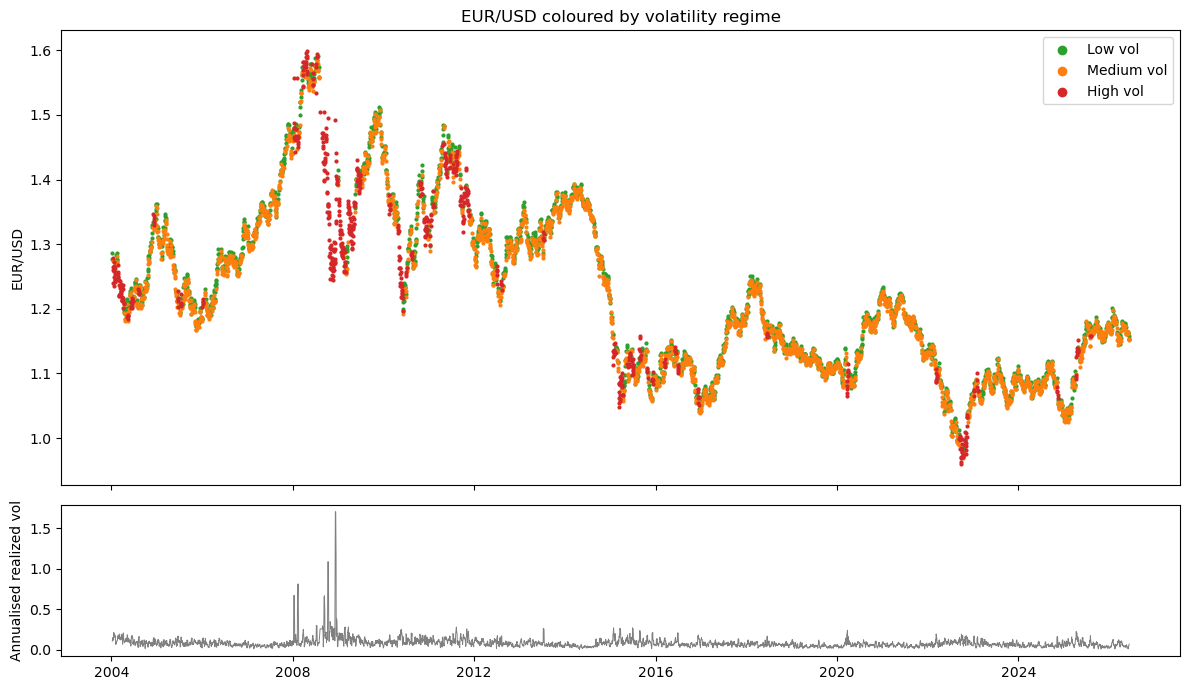

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})
colors = {"Low vol": "#2ca02c", "Medium vol": "#ff7f0e", "High vol": "#d62728"}
price = px.loc[feat.index]
for name in names:
    mask = (regime == name).values
    ax[0].scatter(price.index[mask], price.values[mask], s=4, c=colors[name], label=name)
ax[0].set_title("EUR/USD coloured by volatility regime"); ax[0].set_ylabel("EUR/USD")
ax[0].legend(markerscale=3, loc="upper right")
ax[1].plot(feat.index, feat["rvol"]*np.sqrt(TRADING_DAYS), lw=0.7, color="grey")
ax[1].set_ylabel("Annualised realized vol")
fig.tight_layout(); fig.savefig("fx_vol_regime_results.png", dpi=120); plt.show()

## Limitations
- The number of regimes (3) is a modelling choice; 2 or 4 states give different partitions.
- A Gaussian HMM assumes normally-distributed returns within each state, which understates fat tails.
- Regimes are inferred over the full sample; a live detector would re-fit on a rolling basis to avoid look-ahead in the state labels.
- Daily data is used for a long history and clear regimes; switch to an intraday `interval` for a higher-frequency view (Yahoo limits intraday history to ~2 years).